# TMDB Movie Data Analysis

## Project Overview
This project analyzes movie data fetched from the TMDb API. It includes data cleaning, KPI calculation, advanced filtering (Directors/Cast), and visualization as per the project requirements.

In [1]:
# Importing required libraries to complete the task 
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Fetching
Fetching data from TMDb API using the provided movie IDs.

In [2]:
# Input variables to function fetch movie data
API_KEY = os.getenv('api_key')
BASE_URL = "https://api.themoviedb.org/3/movie/"

movie_ids = [
    0, 299534, 19995, 140607, 299536, 597, 135397, 420818, 24428, 
    168259, 99861, 2840, 12445, 181808, 330457, 351286, 109445, 
    321612, 260513
]

In [3]:
# Function to fetch movie data from TMDb API
def fetch_movie_data(movie_ids, api_key):
    movies_data = []
    if not api_key:
        raise ValueError("API key is required.")
    print(f"TBMb API key verified and we going to fetch data for {len(movie_ids)} movies.")
    print("Fetching data...")
    for movie_id in sorted(movie_ids):
        # Includes 'credits' to get Cast and Crew info
        url = f"{BASE_URL}{movie_id}?api_key={api_key}&language=en-US&append_to_response=credits"
        try:
            response = requests.get(url)
            if response.status_code == 200:
                movies_data.append(response.json())
            else:
                print(f"Error fetching ID {movie_id}: {response.status_code}")
        except Exception as e:
            print(f"Exception for ID {movie_id}: {e}")
    print(f"Fetched data for {len(movies_data)} movies, and failed to fetch data for {len(movie_ids) - len(movies_data)} movies.")
    return movies_data

# fetch data
raw_data = fetch_movie_data(movie_ids, API_KEY)
df_raw = pd.DataFrame(raw_data)

TBMb API key verified and we going to fetch data for 19 movies.
Fetching data...
Error fetching ID 0: 404
Fetched data for 18 movies, and failed to fetch data for 1 movies.


In [4]:
# save data to csv
df_raw.to_csv('tmdb_movies_raw_data.csv', index=False)

## 2. Data Cleaning and Preprocessing

### Data preparation and cleaning

1. Drop irrelevant columns

In [5]:
df =df_raw.copy()
cols_to_drop = ['adult', 'imdb_id', 'original_title', 'video', 'homepage']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

2. Evaluating json columns

In [6]:
json_cols = ['belongs_to_collection', 'genres', 'production_companies', 
             'production_countries', 'spoken_languages']
df[json_cols].head()

,belongs_to_collection,genres,production_companies,production_countries,spoken_languages
0,None,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...","[{'id': 4, 'logo_path': '/jay6WcMgagAklUt7i9Eu...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'english_name': 'English', 'iso_639_1': 'en'..."
1,None,"[{'id': 80, 'name': 'Crime'}, {'id': 10770, 'n...","[{'id': 1245, 'logo_path': '/suKdkPTtHn0DzGYmr...","[{'iso_3166_1': 'FR', 'name': 'France'}, {'iso...","[{'english_name': 'French', 'iso_639_1': 'fr',..."
2,"{'id': 1241, 'name': 'Harry Potter Collection'...","[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...","[{'id': 174, 'logo_path': '/ingPVoHnINIrFR7WHm...","[{'iso_3166_1': 'GB', 'name': 'United Kingdom'...","[{'english_name': 'English', 'iso_639_1': 'en'..."
3,"{'id': 87096, 'name': 'Avatar Collection', 'po...","[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...","[{'id': 444, 'logo_path': None, 'name': 'Dune ...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'english_name': 'English', 'iso_639_1': 'en'..."
4,"{'id': 86311, 'name': 'The Avengers Collection...","[{'id': 878, 'name': 'Science Fiction'}, {'id'...","[{'id': 420, 'logo_path': '/hUzeosd33nzE5MCNsZ...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'english_name': 'English', 'iso_639_1': 'en'..."


3. Extract key colomn data 

In [7]:
# Extract collection names from 'belongs_to_collection' column
if 'belongs_to_collection' in df.columns:
    df['collection_name'] = df['belongs_to_collection'].apply(
        lambda x: x['name'] if isinstance(x, dict) else None
    )

In [8]:
# separate genre names by | from genres column
# separate spoken language names by | from spoken_languages column
# separate production company names by | from production_companies column
# separate production country names by | from production_countries column
def extract_names(data, key):
    if isinstance(data, list):
        return '|'.join([item['name'] for item in data if 'name' in item])
    return None
df['genres'] = df['genres'].apply(lambda x: extract_names(x, 'name'))
df['spoken_languages'] = df['spoken_languages'].apply(lambda x: extract_names(x, 'name'))
df['production_companies'] = df['production_companies'].apply(lambda x: extract_names(x, 'name'))
df['production_countries'] = df['production_countries'].apply(lambda x: extract_names(x, 'name'))

4. Inspect extracted columns using value_counts() to identify anomalies.

In [9]:
extracted_cols = ['collection_name', 'genres', 'spoken_languages', 
                  'production_companies', 'production_countries']

for col in extracted_cols:
    if col in df.columns:
        print(f"\n{col} values count:")
        print(df[col].value_counts())


collection_name values count:
collection_name
The Avengers Collection                4
Jurassic Park Collection               2
Frozen Collection                      2
Star Wars Collection                   2
Harry Potter Collection                1
Avatar Collection                      1
The Fast and the Furious Collection    1
The Incredibles Collection             1
The Lion King (Reboot) Collection      1
Name: count, dtype: int64

genres values count:
genres
Adventure|Action|Science Fiction             3
Action|Adventure|Science Fiction|Thriller    2
Drama|Romance                                1
Action|Adventure|Fantasy|Science Fiction     1
Science Fiction|Action|Adventure             1
Crime|TV Movie|Drama|Mystery                 1
Adventure|Fantasy                            1
Animation|Family|Adventure|Fantasy           1
Action|Adventure|Science Fiction             1
Action|Crime|Thriller                        1
Action|Adventure|Animation|Family            1
Adventure|Sc

### Handling Missing & Incorrect Data

5. Convert column datatype and replace unrealistic values

In [10]:
# 5. Numeric Conversion & Handling 0/NaN
df['budget_musd'] = pd.to_numeric(df['budget'], errors='coerce') / 1000000  # Convert to Millions
df['revenue_musd'] = pd.to_numeric(df['revenue'], errors='coerce') / 1000000 # Convert to Millions
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
df['vote_count'] = pd.to_numeric(df['vote_count'], errors='coerce').fillna(0)

# Replace 0 with NaN for analysis where 0 is invalid
df.loc[df['budget_musd'] <= 0, 'budget_musd'] = np.nan
df.loc[df['revenue_musd'] <= 0, 'revenue_musd'] = np.nan
df.loc[df['runtime'] <= 0, 'runtime'] = np.nan

# Date Handling
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year

7. Remove duplicates and drop rows with unknown 'id' or 'title'.

In [11]:
# Remove duplicates based on a hashable key (use 'id' which is hashable)
df.drop_duplicates(subset='id', inplace=True)

# remove rows with unknown id or title (require both present), how many rows and columns 
# left and cols with missing values
df = df[df['id'].notna() & df['title'].notna()]

# show shape and columns that have missing values
print(f"column: {df.shape[1]}, rows: {df.shape[0]}")
print("\nColumns with missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

column: 26, rows: 18

Columns with missing values:
backdrop_path            1
belongs_to_collection    3
collection_name          3
budget_musd              1
revenue_musd             1
dtype: int64


8. Keep only rows where at least 10 columns have non-NaN values.

In [12]:
df = df.dropna(thresh=10)

9. Filter to include only 'Released' movies, then drop 'status'.

In [13]:
if 'status' in df.columns:
    df = df[df['status'] == 'Released'].drop(columns=['status'])

10. Extract directors and and cast

In [14]:
# 4. Extract Director and Cast
if 'credits' in df.columns:
    def get_director(credits_json):
        if isinstance(credits_json, dict) and 'crew' in credits_json:
            directors = [m['name'] for m in credits_json['crew'] if m.get('job') == 'Director']
            return '|'.join(directors)
        return ''
    def get_cast(credits_json):
        if isinstance(credits_json, dict) and 'cast' in credits_json:
            cast = [m['name'] for m in credits_json['cast']]
            return '|'.join(cast)
        return ''
    df['director'] = df['credits'].apply(get_director)
    df['cast'] = df['credits'].apply(get_cast)

11. Add cast_size and crew size

In [15]:
# cast_size and crew_size
if 'credits' in df.columns:
    def get_cast_size(credits_json):
        if isinstance(credits_json, dict) and 'cast' in credits_json:
            return len(credits_json['cast'])
        return 0
    def get_crew_size(credits_json):
        if isinstance(credits_json, dict) and 'crew' in credits_json:
            return len(credits_json['crew'])
        return 0
    df['cast_size'] = df['credits'].apply(get_cast_size)
    df['crew_size'] = df['credits'].apply(get_crew_size)

12. Reorder columns for better readability

In [16]:
# check if columns exist in df and sort 
sorted_cols = ['id', 'title', 'tagline', 'release_year', 'release_date', 'genres', 'collection_name', 
               'original_language', 'budget_musd', 'revenue_musd', 'production_companies', 
               'production_countries', 'vote_count', 'vote_average', 'popularity', 'runtime', 
               'overview', 'spoken_languages', 'poster_path', 'cast', 'cast_size', 'director', 
               'crew_size']

# check missing col
missing_cols = [col for col in sorted_cols if col not in df.columns]
print("Missing columns in cleaned DataFrame:")
print(missing_cols)

print(len(sorted_cols))
df_cleaned = df[[col for col in sorted_cols if col in df.columns]]
df_cleaned.shape

Missing columns in cleaned DataFrame:
[]
23


(18, 23)

13. Remain columns profit and roi

In [17]:
df_cleaned.loc[:, 'profit_musd'] = df_cleaned['revenue_musd'] - df_cleaned['budget_musd']
df_cleaned.loc[:, 'roi'] = df_cleaned['profit_musd'] / df_cleaned['budget_musd']
df_cleaned.loc[:, 'is_franchise'] = df_cleaned['collection_name'].notna()

C:\Users\Ernest PC\AppData\Local\Temp\ipykernel_21464\124936055.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.loc[:, 'profit_musd'] = df_cleaned['revenue_musd'] - df_cleaned['budget_musd']
C:\Users\Ernest PC\AppData\Local\Temp\ipykernel_21464\124936055.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.loc[:, 'roi'] = df_cleaned['profit_musd'] / df_cleaned['budget_musd']
C:\Users\Ernest PC\AppData\Local\Temp\ipykernel_21464\124936055.py:3: SettingWithCopyWarning: 
A value is try

In [18]:
# describe numeric columns
df_cleaned.describe().T

,count,mean,min,25%,50%,75%,max,std
id,18.0,176635.444444,597.0,43286.25,154433.0,299535.5,420818.0,137501.215463
release_year,18.0,2012.611111,1980.0,2012.25,2015.0,2018.0,2019.0,9.684061
release_date,18,2013-03-06 17:20:00,1980-08-29 00:00:00,2012-09-15 12:00:00,2015-09-10 00:00:00,2018-05-26 12:00:00,2019-11-20 00:00:00,NaN
budget_musd,17.0,214.588235,125.0,160.0,200.0,245.0,356.0,63.768192
revenue_musd,17.0,1711.94393,1243.225667,1332.69883,1515.4,2052.415039,2923.706026,529.848115
vote_count,18.0,19269.444444,0.0,12709.75,18720.5,25971.75,34872.0,9185.254149
vote_average,18.0,6.983611,0.0,7.0015,7.251,7.821,8.237,1.816299
popularity,18.0,22.570244,0.1308,11.111725,14.34445,19.983475,96.5148,22.023807
runtime,18.0,135.722222,93.0,119.5,133.0,147.5,194.0,26.112439
cast_size,18.0,81.5,12.0,54.75,71.5,110.0,183.0,42.828317


In [19]:
# decribe categorical columns
df_cleaned.describe(include=['object', 'bool']).T

,count,unique,top,freq
title,18,18,Titanic,1
tagline,18,18,Nothing on earth could come between them.,1
genres,18,15,Adventure|Action|Science Fiction,3
collection_name,15,9,The Avengers Collection,4
original_language,18,2,en,17
production_companies,18,14,Marvel Studios,4
production_countries,18,4,United States of America,15
overview,18,18,101-year-old Rose DeWitt Bukater tells the sto...,1
spoken_languages,18,10,English,9
poster_path,18,18,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,1


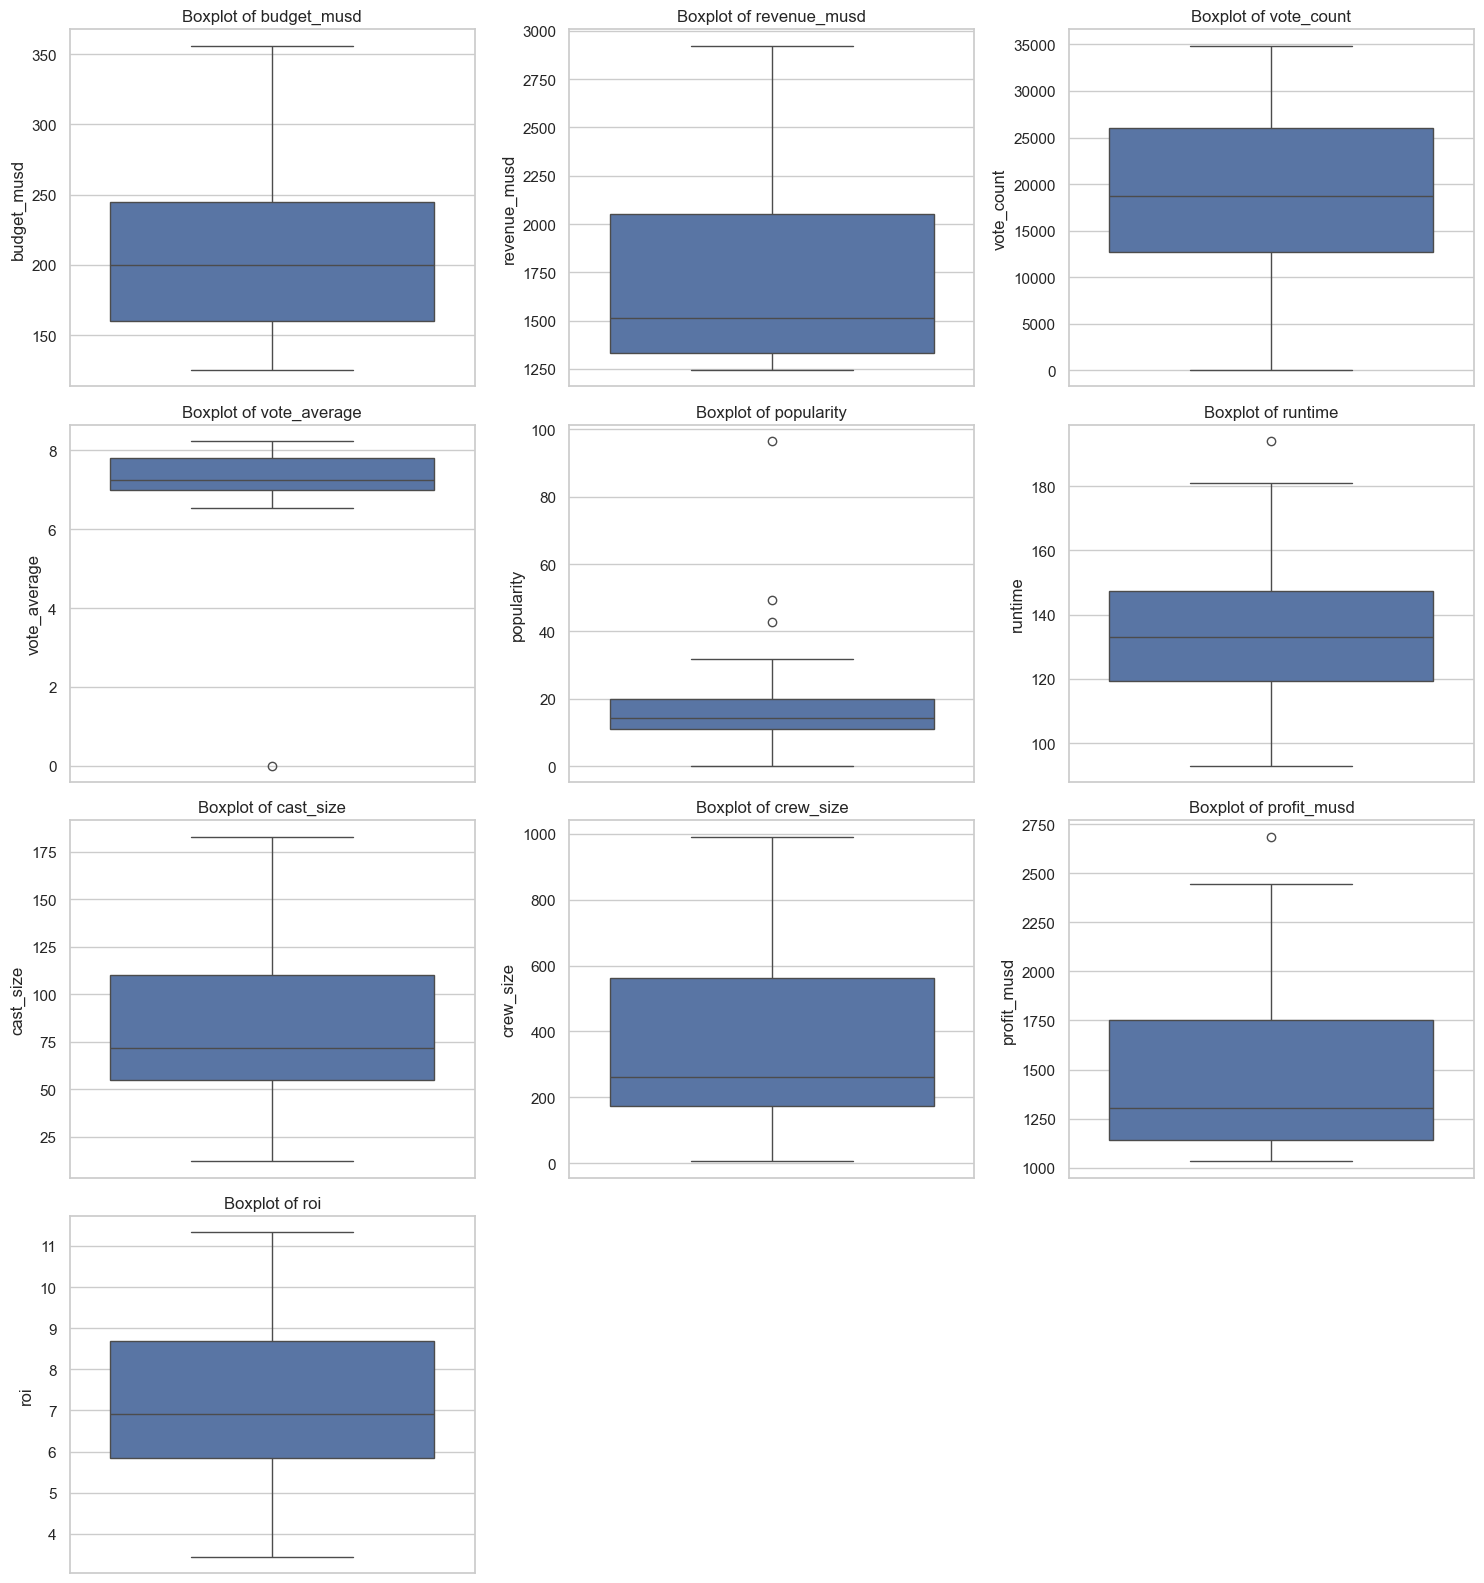

In [20]:
# check outliers by subplots boxplot
def box_dist(data):
    make_subplots = True
    num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    num_cols.remove('id')  # Exclude 'id' from outlier treatment
    num_cols.remove('release_year')  # Exclude 'release_year' from outlier treatment
    if make_subplots:
        cols_per_row = 3
        rows = int(np.ceil(len(num_cols) / cols_per_row))
        fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row*5, rows*4))
        axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
        for ax, col in zip(axes, num_cols):
            sns.boxplot(y=df_cleaned[col], ax=ax)
            ax.set_title(f'Boxplot of {col}')
        for ax in axes[len(num_cols):]:
            ax.set_visible(False)
        plt.tight_layout()
        plt.show()
    else:
        for col in num_cols:
            plt.figure(figsize=(6,4))
            sns.boxplot(y=data[col])
            plt.title(f'Boxplot of {col}')
            plt.show()

box_dist(df_cleaned)

In [21]:
# Replace outliers with the median
def remove_outliers(data):
    num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    num_cols.remove('id')  # Exclude 'id' from outlier treatment
    num_cols.remove('release_year')  # Exclude 'release_year' from outlier treatment
    for col in num_cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        median = data[col].median()
        data.loc[:, col] = np.where(data[col] < lower_bound, median,
                           np.where(data[col] > upper_bound, median, data[col]))
    return data

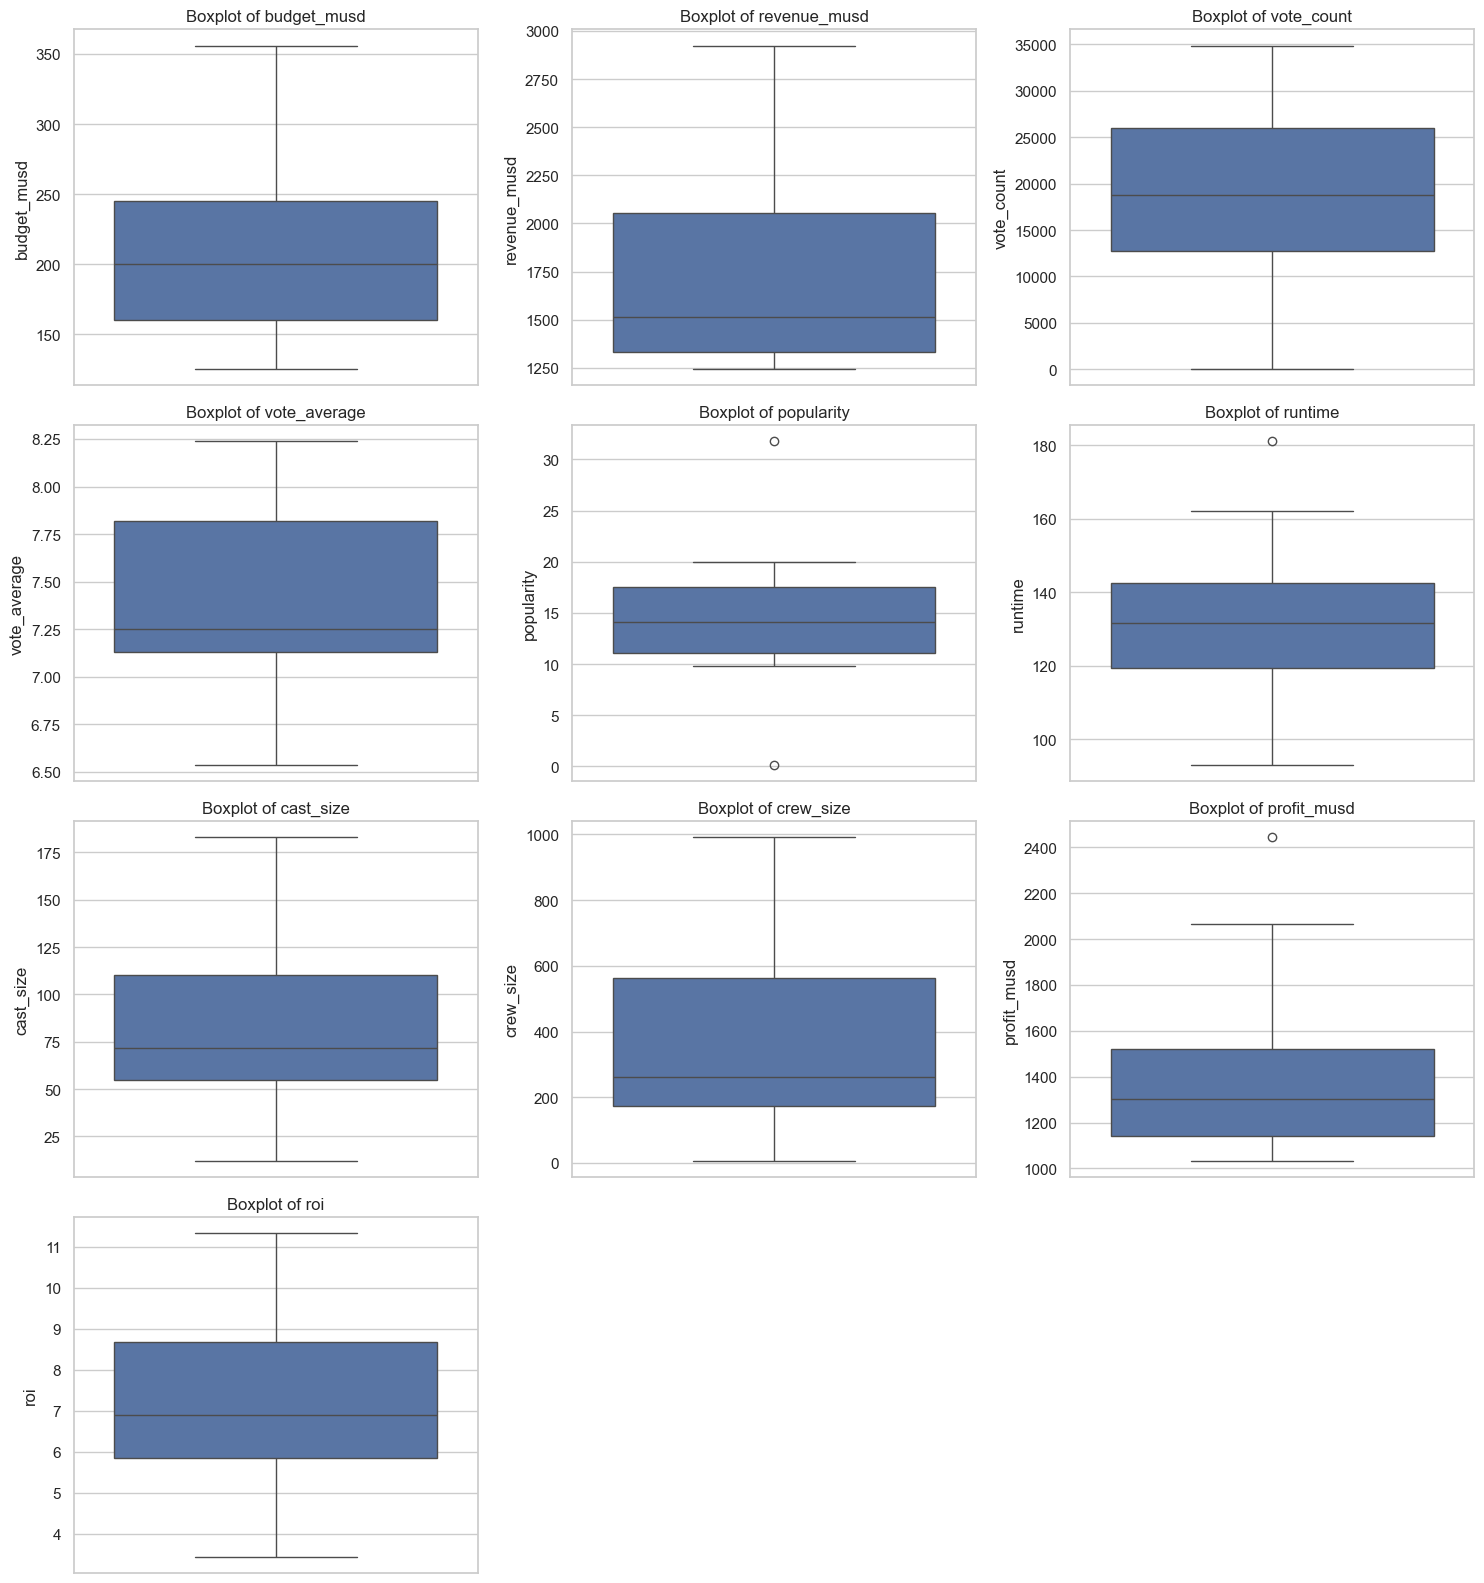

In [22]:
df_cleaned = remove_outliers(df_cleaned)
box_dist(df_cleaned)

In [23]:
# save cleaned data to csv
# df_cleaned.to_csv('tmdb_movies_cleaned.csv', index=False)

### 3.1 Rankings and Performance Analysis
1. Filter and rank movies based on: Revenue, Budget, Profit, ROI, Rating, and Popularity.

In [24]:
df_cleaned = pd.read_csv('tmdb_movies_cleaned.csv')
df_cleaned.columns

Index(['id', 'title', 'tagline', 'release_year', 'release_date', 'genres',
       'collection_name', 'original_language', 'budget_musd', 'revenue_musd',
       'production_companies', 'production_countries', 'vote_count',
       'vote_average', 'popularity', 'runtime', 'overview', 'spoken_languages',
       'poster_path', 'cast', 'cast_size', 'director', 'crew_size',
       'profit_musd', 'roi', 'is_franchise'],
      dtype='object')

In [25]:
def analyze_kpi(df):
    # Helper to print tables
    def print_top_bottom(metric, label, ascending=False, n=5):
        print(f"\nTop {n} {label}" if not ascending else f"\nLowest {n} {label}")
        if ascending:
            print(df.nsmallest(n, metric)[['title', metric]])
        else:
            print(df.nlargest(n, metric)[['title', metric]])

    # 1. Revenue
    print_top_bottom('revenue_musd', 'Revenue')
    
    # 2. Budget
    print_top_bottom('budget_musd', 'Budget')
    print_top_bottom('budget_musd', 'Budget', ascending=True) # Lowest Budget

    # 3. Profit
    print_top_bottom('profit_musd', 'Profit')
    print_top_bottom('profit_musd', 'Profit (Worst)', ascending=True)
    
    # 4. ROI (Budget >= 10M for meaningful comparison)
    roi_df = df[df['budget_musd'] >= 10]
    print("\nTop 5 ROI (Budget >= 10M)")
    print(roi_df.nlargest(5, 'roi')[['title', 'budget_musd', 'revenue_musd', 'roi']])
    
    # 5. Rating (Vote Count >= 10)
    rated_df = df[df['vote_count'] >= 10]
    print("\nTop 5 Rated (Votes >= 10)")
    print(rated_df.nlargest(5, 'vote_average')[['title', 'vote_average', 'vote_count']])
    
    print("\nLowest 5 Rated (Votes >= 10)")
    print(rated_df.nsmallest(5, 'vote_average')[['title', 'vote_average', 'vote_count']])
    
    # 6. Popularity
    print_top_bottom('popularity', 'Popularity')
    
    # 7 Most Voted Movies
    print_top_bottom('vote_count', 'Vote Count')

analyze_kpi(df_cleaned)


Top 5 Revenue
                           title  revenue_musd
3                         Avatar   2923.706026
12             Avengers: Endgame   2799.439100
0                        Titanic   2264.162353
8   Star Wars: The Force Awakens   2068.223624
13        Avengers: Infinity War   2052.415039

Top 5 Budget
                           title  budget_musd
12             Avengers: Endgame        356.0
10      Star Wars: The Last Jedi        300.0
13        Avengers: Infinity War        300.0
17                 The Lion King        260.0
8   Star Wars: The Force Awakens        245.0

Lowest 5 Budget
                                           title  budget_musd
2   Harry Potter and the Deathly Hallows: Part 2        125.0
6                                         Frozen        150.0
7                                 Jurassic World        150.0
15                                     Frozen II        150.0
14                          Beauty and the Beast        160.0

Top 5 Profit
          

### 3.2 Specific Search Queries

2. Filter the dataset for specific queries:

In [43]:
df_cleaned.columns

Index(['id', 'title', 'tagline', 'release_year', 'release_date', 'genres',
       'collection_name', 'original_language', 'budget_musd', 'revenue_musd',
       'production_companies', 'production_countries', 'vote_count',
       'vote_average', 'popularity', 'runtime', 'overview', 'spoken_languages',
       'poster_path', 'cast', 'cast_size', 'director', 'crew_size',
       'profit_musd', 'roi', 'is_franchise'],
      dtype='object')

In [ ]:
 # 1. Bruce Willis + Sci-Fi + Action
bruce_sci_fi = df_cleaned[
    (df_cleaned['cast'].str.contains('Bruce Willis', na=False, case=False)) &
    (df_cleaned['genres'].str.contains('Science Fiction', na=False, case=False)) |
    (df_cleaned['genres'].str.contains('Action', na=False, case=False))
].sort_values('vote_average', ascending=False)
print("\nBruce Willis (Sci-Fi / Action)")
bruce_sci_fi[['title', 'vote_average', 'revenue_musd','genres','cast']]



Bruce Willis (Sci-Fi / Action)


,title,vote_average,revenue_musd,genres,cast
12,Avengers: Endgame,8.237,2799.439100,Adventure|Science Fiction|Action,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...
13,Avengers: Infinity War,8.235,2052.415039,Adventure|Action|Science Fiction,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...
4,The Avengers,7.895,1518.815515,Science Fiction|Action|Adventure,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...
3,Avatar,7.599,2923.706026,Action|Adventure|Fantasy|Science Fiction,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...
11,Incredibles 2,7.455,1243.225667,Action|Adventure|Animation|Family,Craig T. Nelson|Holly Hunter|Sarah Vowell|Huck...
8,Star Wars: The Force Awakens,7.300,2068.223624,Adventure|Action|Science Fiction,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...
5,Avengers: Age of Ultron,7.271,1405.403694,Action|Adventure|Science Fiction,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...
9,Furious 7,7.221,1515.400000,Action|Crime|Thriller,Vin Diesel|Paul Walker|Dwayne Johnson|Michelle...
10,Star Wars: The Last Jedi,6.762,1332.698830,Adventure|Action|Science Fiction,Mark Hamill|Carrie Fisher|Adam Driver|Daisy Ri...
7,Jurassic World,6.700,1671.537444,Action|Adventure|Science Fiction|Thriller,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...


In [48]:
# 2. Tarantino + Uma Thurman
tarantino_uma = df_cleaned[
    (df_cleaned['director'].str.contains('Quentin Tarantino', na=False, case=False)) &
    (df_cleaned['cast'].str.contains('Uma Thurman', na=False, case=False))
].sort_values(by='runtime', ascending=True)
print("\nTarantino & Uma Thurman")
print(tarantino_uma[['title', 'release_date', 'revenue_musd']])


Tarantino & Uma Thurman
Empty DataFrame
Columns: [title, release_date, revenue_musd]
Index: []


### 3.3 Comparative Analysis (Franchise & Director)

3. Compare Franchise and non francise movies

In [28]:
# Aggregate metrics
franchise_stats = df_cleaned.groupby('is_franchise').agg({
    'revenue_musd': 'mean',
    'budget_musd': 'mean',
    'roi': 'median',
    'popularity': 'mean',
    'vote_average': 'mean',
    'title': 'count'
}).rename(columns={'title': 'movie count', 
                   'roi': 'median roi', 
                   'vote_average': 'mean rating', 
                   'popularity': 'mean popularity',
                   'revenue_musd': 'mean revenue (M USD)',
                   'budget_musd': 'mean budget (M USD)'})

print("\nFranchise vs Standalone Comparison")
franchise_stats


Franchise vs Standalone Comparison


,mean revenue (M USD),mean budget (M USD),median roi,mean popularity,mean rating,movie count
is_franchise,,,,,,
False,1765.139159,180.0,8.617018,13.256825,7.387167,3
True,1704.851233,219.2,6.863593,12.543035,7.392000,15


4. Most succuessfull franchize movies

In [29]:
# Most Successful Franchises movie based on Total Revenue, Budget and Ratings
def most_successful_franchises(movie_df):
    df = movie_df[movie_df['is_franchise']==True]
    franchise_ranking = df.groupby(['collection_name']).agg({
        'revenue_musd': 'sum',
        'budget_musd': 'sum',
        'vote_average': 'mean',
        'title': 'count'
    }).rename(columns={
        'revenue_musd': 'total revenue (M USD)',
        'budget_musd': 'total budget (M USD)',
        'vote_average': 'mean rating',
        'title': 'movie count'
    }).sort_values('total revenue (M USD)', ascending=False)
    
    for col in franchise_ranking.columns:
        print(f"\nTop 5 Franchises movies by {col}")
        print(franchise_ranking.nlargest(5, col)[[col]])

In [30]:
most_successful_franchises(df_cleaned)


Top 5 Franchises movies by total revenue (M USD)
                          total revenue (M USD)
collection_name                                
The Avengers Collection             7776.073348
Star Wars Collection                3400.922454
Jurassic Park Collection            2982.006481
Avatar Collection                   2923.706026
Frozen Collection                   2727.902485

Top 5 Franchises movies by total budget (M USD)
                                   total budget (M USD)
collection_name                                        
The Avengers Collection                          1111.0
Star Wars Collection                              545.0
Jurassic Park Collection                          320.0
Frozen Collection                                 300.0
The Lion King (Reboot) Collection                 260.0

Top 5 Franchises movies by mean rating
                            mean rating
collection_name                        
Harry Potter Collection          8.0830
The Avengers 

5. Most Successful Director based on  Total Revenue, movies directed, and average rating

In [31]:
def most_successful_directors(movie_df):
    df = movie_df
    director_stats = df.groupby('director').agg({
        'revenue_musd': 'sum',
        'title': 'count',
        'vote_average': 'mean'
    }).rename(columns={
        'revenue_musd': 'total revenue (M USD)',
        'title': 'movies directed',
        'vote_average': 'average rating'
    }).sort_values('total revenue (M USD)', ascending=False)
    
    for col in director_stats.columns:
        print(f"\nTop 5 Directors by {col}")
        print(director_stats.nlargest(5, col)[[col]])

most_successful_directors(df_cleaned)


Top 5 Directors by total revenue (M USD)
                         total revenue (M USD)
director                                      
James Cameron                      5187.868379
Joss Whedon                        2924.219209
Anthony Russo|Joe Russo            2799.439100
Jennifer Lee|Chris Buck            2727.902485
J.J. Abrams                        2068.223624

Top 5 Directors by movies directed
                         movies directed
director                                
James Cameron                          2
Joss Whedon                            2
Jennifer Lee|Chris Buck                2
Anthony Russo|Joe Russo                1
J.J. Abrams                            1

Top 5 Directors by average rating
                         average rating
director                               
Anthony Russo|Joe Russo          8.2370
Joe Russo|Anthony Russo          8.2350
David Yates                      8.0830
James Cameron                    7.7505
Joss Whedon                    

## 4. Visualizations

1. Budget vs revenue trend

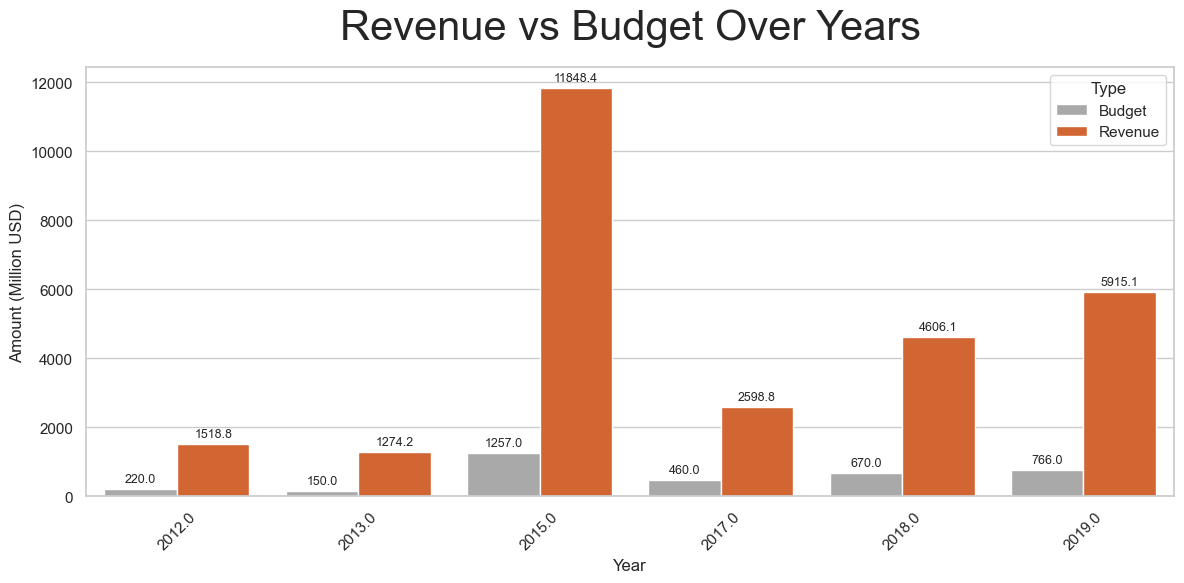

In [32]:
# 1. Revenue vs Budget trend
yearly_data = (df_cleaned.groupby('release_year')[['revenue_musd', 'budget_musd']]
               .sum().reset_index().drop(0)
               .rename(columns={'revenue_musd': 'Revenue', 'budget_musd': 'Budget'}))
yearly_data_melted = yearly_data.melt(id_vars='release_year', var_name='Type', value_name='Amount').sort_values(by=['release_year', 'Type'])

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=yearly_data_melted, 
                 x='release_year', 
                 y='Amount', 
                 hue='Type', 
                 palette=['darkgray', '#eb5d19'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, rotation=0, fontsize=9)
plt.title('Revenue vs Budget Over Years', fontsize=30, pad=20)
plt.xlabel('Year')
plt.ylabel('Amount (Million USD)')
plt.legend(title='Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

2. ROI Distribution by Genre

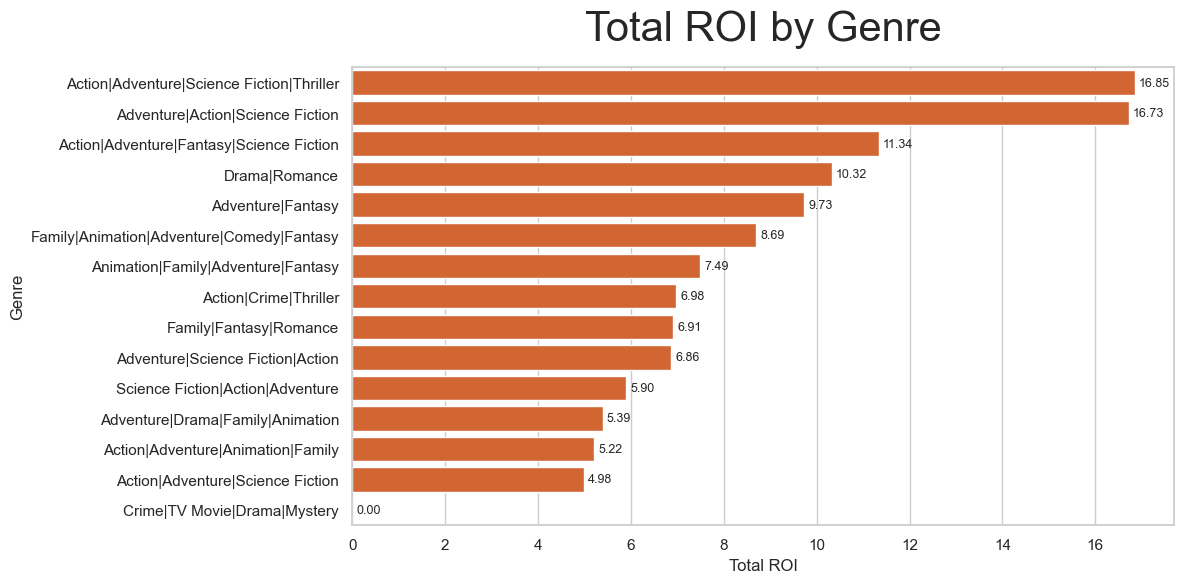

In [38]:
# ROI Distribution by Genre
genre_roi = df_cleaned.groupby('genres')['roi'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=genre_roi.values, y=genre_roi.index, color='#eb5d19')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, rotation=0, fontsize=9)
plt.title('Total ROI by Genre', fontsize=30, pad=20)
plt.xlabel('Total ROI')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

3. Yearly Box Office Trends (Total Revenue)

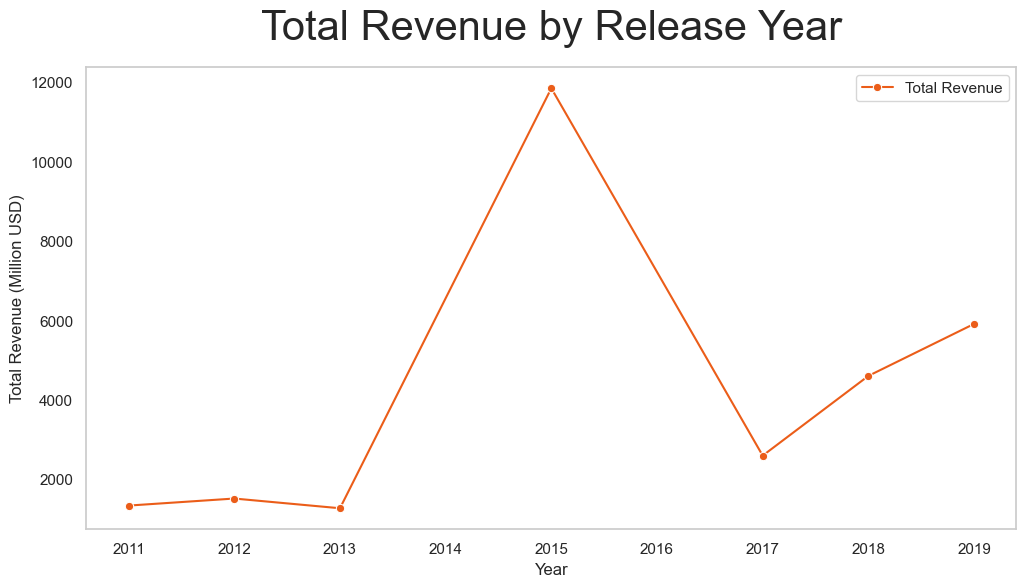

In [39]:
# 3. Yearly Box Office Trends (Total Revenue)
yearly_rev = df_cleaned.groupby('release_year')['revenue_musd'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(data=yearly_rev, x='release_year', y='revenue_musd', 
             marker='o',label='Total Revenue', color='#eb5d19')
plt.title('Total Revenue by Release Year', fontsize=30, pad=20 )
plt.ylabel('Total Revenue (Million USD)')
# plt.xticks(rotation=45)
plt.xlabel('Year')
plt.grid(False)
plt.show()

4. Popularity vs Rating


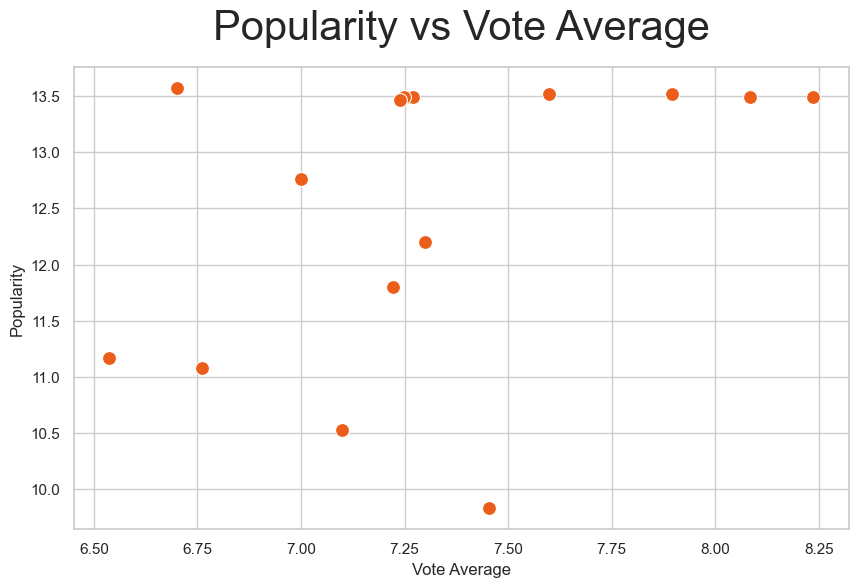

In [40]:
df = df_cleaned[['popularity', 'vote_average']].drop(0)
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='vote_average', y='popularity', s=100, color='#eb5d19')
plt.title('Popularity vs Vote Average', fontsize=30, pad=20)
plt.xlabel('Vote Average')
plt.ylabel('Popularity')
plt.show()

5. Franchise Comparison Charts

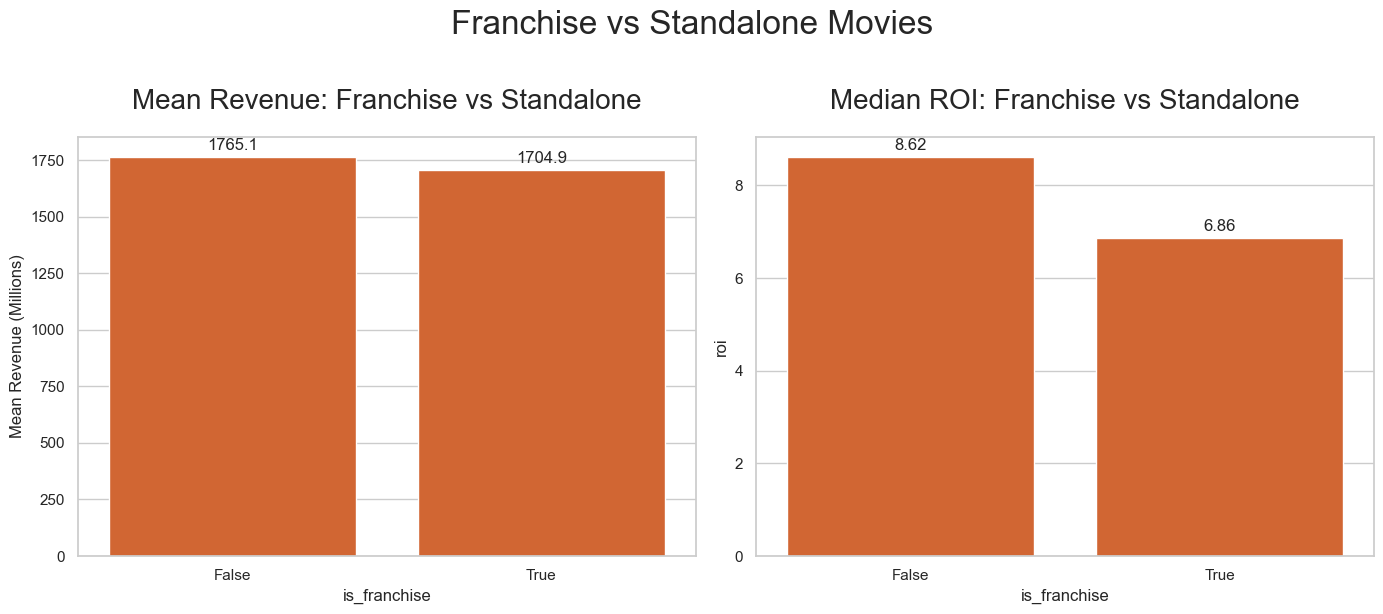

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plt.suptitle('Franchise vs Standalone Movies', fontsize=24, y=1.02)
# Mean Revenue
sns.barplot(data=df_cleaned, x='is_franchise', y='revenue_musd', ax=axes[0], errorbar=None, color='#eb5d19')
axes[0].set_title('Mean Revenue: Franchise vs Standalone', fontsize=20, pad=20)
axes[0].set_ylabel('Mean Revenue (Millions)')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', padding=3)

# Median ROI
sns.barplot(data=df_cleaned, x='is_franchise', y='roi', estimator=np.median, ax=axes[1], errorbar=None, color='#eb5d19')
axes[1].set_title('Median ROI: Franchise vs Standalone', fontsize=20, pad=20)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()